Data Loading

In [5]:
import pandas as pd

df = pd.read_csv(r"C:\Users\USER\Documents\complaints_processed.csv")

print(df.head())

   Unnamed: 0           product  \
0           0       credit_card   
1           1       credit_card   
2           2    retail_banking   
3           3  credit_reporting   
4           4  credit_reporting   

                                           narrative  
0  purchase order day shipping amount receive pro...  
1  forwarded message date tue subject please inve...  
2  forwarded message cc sent friday pdt subject f...  
3  payment history missing credit report speciali...  
4  payment history missing credit report made mis...  


In [6]:
import nltk
import re
from nltk.corpus import stopwords

In [11]:
print(df.columns.tolist())

['Unnamed: 0', 'product', 'narrative']


In [14]:
stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()

    text = re.sub(r"[^a-zA-Z]", " ",text)

    words = text.split()

    words = [w for w in words if w not in stop_words]

    return " ".join(words)

df["clean_text"] = df["narrative"].fillna("").apply(clean_text)

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [16]:
vectorizer = TfidfVectorizer(max_features=5000)

In [18]:
x = vectorizer.fit_transform(df["clean_text"])
y = df["product"]

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


In [23]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [24]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [27]:
from sklearn.metrics import accuracy_score

In [28]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.87


In [29]:
y_pred = model.predict(x_test)
print(classification_report(y_test, y_pred))

                     precision    recall  f1-score   support

        credit_card       0.79      0.79      0.79      3212
   credit_reporting       0.90      0.93      0.92     18130
    debt_collection       0.79      0.71      0.75      4619
mortgages_and_loans       0.85      0.82      0.83      3738
     retail_banking       0.87      0.87      0.87      2786

           accuracy                           0.87     32485
          macro avg       0.84      0.82      0.83     32485
       weighted avg       0.87      0.87      0.87     32485



Overall Accuracy: 87% - the model correctly classifies 87% of complaints
What it means per product:
Credit Reporting - F1:0.92 - Easiest to identify- very distinct language
Retail Banking  - F1:0.87 - Well recognized complaint patterns
Mortgages and Loans - F1:0.83 - Good but some overlap with other categories
Credit Card - F1:0.79 - Some complaints misclassified
Debt Collection - F1:0.75 - Hardest to classify - language overlaps with others


In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

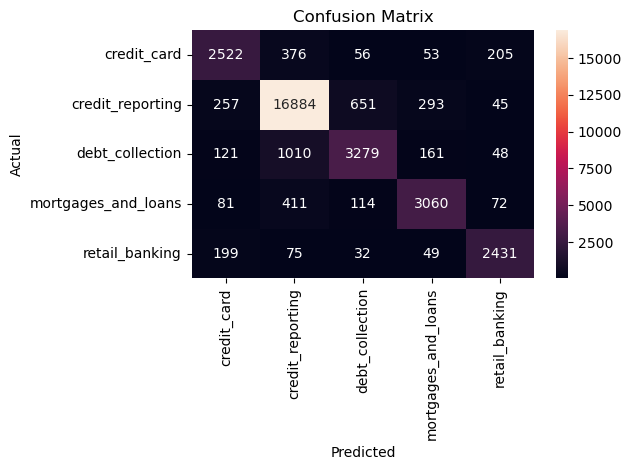

In [31]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model.classes_, yticklabels=model.classes_)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [44]:
# Top words driving each product category
import matplotlib.pyplot as plt
import numpy as np

In [46]:
feature_names = np.array(vectorizer.vocabulary_)

for i, class_ in enumerate(model.classes_):
    top_indices = model.coef_[i].argsort()[-10:]
    top_words = [word for word, idx in vectorizer.vocabulary_.items() if idx in top_indices]
    print(f"\n{class_}: {list(top_words)}")


credit_card: ['card', 'credit', 'interest', 'merchant', 'citi', 'synchrony', 'barclay', 'reward', 'reliacard', 'prepaid']

credit_reporting: ['remove', 'credit', 'reporting', 'report', 'transunion', 'experian', 'bureau', 'equifax', 'inquiry', 'trans']

debt_collection: ['credit', 'debt', 'report', 'collection', 'owe', 'owed', 'recovery', 'collect', 'llc', 'midland']

mortgages_and_loans: ['loan', 'mortgage', 'escrow', 'principal', 'closing', 'title', 'appraisal', 'lending', 'loancare', 'navient']

retail_banking: ['transaction', 'bank', 'branch', 'debit', 'fund', 'money', 'paypal', 'checking', 'pnc', 'coinbase']


In [48]:
import pickle

pickle.dump(model, open("complaint_classifier.pkl", "wb"))
pickle.dump(vectorizer,open("vectorizer.pkl","wb"))

In [34]:
import pickle

In [35]:
model = pickle.load(open("complaint_model.pkl","rb"))
vectorizer = pickle.load(open("vectorizer.pkl","rb"))



In [50]:
def predict_complaint(text):
    cleaned = clean_text(text)

    vectorized = vectorizer.transform([cleaned])

    return model.predict(vectorized)[0]



In [54]:
predict_complaint("I have an error on my credit bureau")

'credit_reporting'